<a href="https://colab.research.google.com/github/husthorng/Backpropagation_NN/blob/main/2026_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#https://docs.google.com/presentation/d/1qqGxfT7zR6U5LKb76zorLoxtujJ2-P11/edit?usp=sharing&ouid=111232199303587124698&rtpof=true&sd=true
#https://docs.google.com/spreadsheets/d/1MCLzwhxs2HAWVtvSjVqnYFypObzEoAu2RhhC02EjZ8I/edit?usp=sharing
import numpy as np
def sigmoid(x):
    return 1/(1+np.exp(-x))
def sigmoid_derivative(x):
    return x*(1-x)
training_input=np.array([[0,0,1],
             [1,1,1],
             [1,0,1],
             [0,1,1]])
training_outputs=np.array([[0,1,1,0]]).T
np.random.seed(15)
synaptic_weigths=2*np.random.random((3,1))-1
print("Random start synaptic weigths:")
print(synaptic_weigths)
for iteration in range(2000):
    input_layer=training_input
    outputs=sigmoid(np.dot(input_layer,synaptic_weigths))
    error=training_outputs-outputs
    adjustment=error*sigmoid_derivative(outputs)
    synaptic_weigths += np.dot(input_layer.T,adjustment)
print('synaptic weigths after training:')
print(synaptic_weigths)
print('Outputs after training:')
print(outputs)
error=training_outputs-outputs
adjustment=error*sigmoid_derivative(outputs)
synaptic_weigths += np.dot(input_layer.T,adjustment)
print('synaptic weigths after training:')
print(synaptic_weigths)
print('Outputs after training:')
print(outputs)


Random start synaptic weigths:
[[ 0.69763539]
 [-0.64220815]
 [-0.89127357]]
synaptic weigths after training:
[[ 8.00451867]
 [-0.21646487]
 [-3.78882976]]
Outputs after training:
[[0.02212739]
 [0.98199541]
 [0.98544887]
 [0.01789755]]
synaptic weigths after training:
[[ 8.00504565]
 [-0.21646113]
 [-3.78909615]]
Outputs after training:
[[0.02212739]
 [0.98199541]
 [0.98544887]
 [0.01789755]]


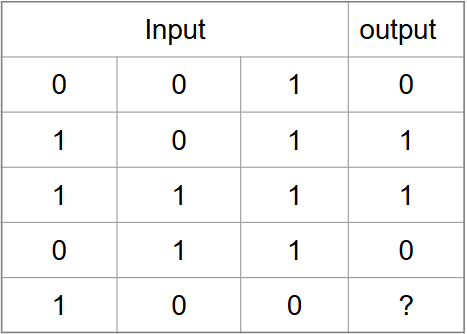

寫colab程式 將陣列內容
[[ -6.10702768  -0.02378871   0.08491156]
 [ 10.87501137  -2.91687111  -4.41559737]
 [-16.48069095  -0.21220732   0.96076879]]
轉成有逗號的陣列內容
[[-3.86691116,7.40920991,-11.77842005],
 [-0.16707528,-1.98081406,-0.36680751],
 [-0.07027842,-2.95002294,0.90453073]]

In [ ]:
import numpy as np
def nonlin(x,deriv=False):
    A=1/(1+np.exp(-x))
    if(deriv==True):
        return (A*(1-A))
    return A

InputD=np.array([1,0,1])
W0=np.array([
 [-3.86691116,7.40920991,-11.77842005],
 [-0.16707528,-1.98081406,-0.36680751],
 [-0.07027842,-2.95002294,0.90453073]
 ])
SIW0=InputD@W0
print(SIW0)                #[-0.07027842 -2.95002294  0.90453073]
nonlin_SIW0=nonlin(SIW0,deriv=False)
print(nonlin_SIW0)     #[0.48243762 0.04973543 0.71187968]

W1=np.array([
 [-3.26440319],
 [6.43803832],
 [-7.25553539]
 ])
SHW1=nonlin_SIW0@W1
print(SHW1)                                 #[-6.41974053]
nonlin_SHW1=nonlin(SHW1,deriv=False)
print(nonlin_SHW1)                      #[0.00162643]


[ -3.93718958   4.45918697 -10.87388932]
[1.91298606e-02 9.88560606e-01 1.89461793e-05]
[6.30180602]
[0.99817036]


In [ ]:
import numpy as np
import pandas as pd
records1=np.array([[0, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [0, 1, 1, 0]])

records = pd.DataFrame(records1) #轉pandas結構

print(records)


np.random.seed(9)
#1 np.random.seed(7)


numTag=1
hidden_node=3

inputD=records.iloc[0:records.shape[0],0:records.shape[1]-numTag].values
print(inputD.shape)
tagetD=records.iloc[:,list(records.shape[1]-np.arange(numTag,0,-1))].values
print(inputD)
print(tagetD)

np.random.seed(1) #np.random.seed(1) are the weights that on paper
syn0=2*np.random.random((inputD.shape[1],hidden_node))-1
syn1=2*np.random.random((hidden_node,numTag))-1



def nonlin(x,deriv=False):
    A=1/(1+np.exp(-x))
    if(deriv==True):
        return (A*(1-A))
    return A




for j in range(12000):
    X=inputD
    L0=nonlin(np.dot(inputD,syn0))
    L1=nonlin(np.dot(L0,syn1))
    #print(L1)
    L1_error=tagetD-L1
    if(j % 100)==0:
        print("Error"+str(np.mean(np.abs(L1_error))))
    #print(L1_error)
    L1_delta=L1_error*nonlin(L1,deriv=True)
    #print(L1_delta)
    L0_error=L1_delta.dot(syn1.T)
    L0_delta=L0_error*nonlin(L0,deriv=True)
    syn1 += L0.T.dot(L1_delta)
    syn0 += inputD.T.dot(L0_delta)

print("output after Training:")
# np.savetxt("syn0.csv", syn0, delimiter=",")
# np.savetxt("syn1.csv", syn1, delimiter=",")
#print(syn0)

df0 = pd.DataFrame(syn0.transpose())
L1=np.where(L1 > 0.9, 1, 0)

df0.to_csv("syn0.csv")
df1 = pd.DataFrame(syn1.transpose())
df1.to_csv("syn1.csv")
print(L1)
print(syn0)
print(syn0.transpose())
print(syn1)



   0  1  2  3
0  0  0  1  0
1  1  0  1  1
2  1  1  1  1
3  0  1  1  0
(4, 3)
[[0 0 1]
 [1 0 1]
 [1 1 1]
 [0 1 1]]
[[0]
 [1]
 [1]
 [0]]
Error0.5108456683181672
Error0.09030563422437302
Error0.02335732624713261
Error0.012477066198851212
Error0.008362112981354032
Error0.00624348060215945
Error0.004963509645368029
Error0.00411056665914738
Error0.0035032451450147713
Error0.0030496506010513967
Error0.002698427085496544
Error0.0024186942404409717
Error0.0021907997630134287
Error0.002001657309269658
Error0.0018422240777944323
Error0.0017060557055291318
Error0.001588438232240668
Error0.0014858455036072969
Error0.0013955882673551776
Error0.0013155804716455982
Error0.0012441795755967371
Error0.001180074939339943
Error0.001122208237737118
Error0.0010697156832271896
Error0.0010218854001367728
Error0.0009781255157362751
Error0.0009379399555172817
Error0.0009009098595123995
Error0.0008666791555682885
Error0.0008349432451888108
Error0.000805440046722688
Error0.0007779428428555263
Error0.00075225452267

syn0與syn1大入NN_3_1.ipynb

In [ ]:
syn0

array([[ -6.10702768,  10.87501137, -16.48069095],
       [ -0.02378871,  -2.91687111,  -0.21220732],
       [  0.08491156,  -4.41559737,   0.96076879]])

In [ ]:
syn1

array([[-4.52468611],
       [ 8.64139943],
       [-9.04502342]])

傳至Arduino 需轉置 syn0.T

In [ ]:
syn0.T

array([[ -6.10702768,  -0.02378871,   0.08491156],
       [ 10.87501137,  -2.91687111,  -4.41559737],
       [-16.48069095,  -0.21220732,   0.96076879]])

In [ ]:
import numpy as np
def nonlin(x,deriv=False):
    A=1/(1+np.exp(-x))
    if(deriv==True):
        return (A*(1-A))
    return A

InputD=np.array([
    [0,0,1],
    [1,0,1],
    [1,1,1],
    [0,1,1]
    ])
W0=np.array([[ -6.10702768,  10.87501137, -16.48069095],
       [ -0.02378871,  -2.91687111,  -0.21220732],
       [  0.08491156,  -4.41559737,   0.96076879]])
SIW0=InputD@W0
print(SIW0)
nonlin_SIW0=nonlin(SIW0,deriv=False)
print(nonlin_SIW0)

W1=np.array([[-4.52468611],
       [ 8.64139943],
       [-9.04502342]])
SHW1=nonlin_SIW0@W1
print(SHW1)
nonlin_SHW1=nonlin(SHW1,deriv=False)
print(nonlin_SHW1)


[[  0.08491156  -4.41559737   0.96076879]
 [ -6.02211612   6.459414   -15.51992216]
 [ -6.04590483   3.54254289 -15.73212948]
 [  0.06112285  -7.33246848   0.74856147]]
[[5.21215145e-01 1.19429727e-02 7.23275703e-01]
 [2.41866941e-03 9.98436735e-01 1.81879339e-07]
 [2.36194566e-03 9.71874304e-01 1.47103469e-07]
 [5.15275957e-01 6.53529932e-04 6.78865170e-01]]
[[-8.7971766 ]
 [ 8.61694526]
 [ 8.38766567]
 [-8.46616591]]
[[1.51136410e-04]
 [9.99819020e-01]
 [9.99772394e-01]
 [2.10426031e-04]]


In [ ]:
import numpy as np
def nonlin(x,deriv=False):
    A=1/(1+np.exp(-x))
    if(deriv==True):
        return (A*(1-A))
    return A

InputD=np.array([
    [0,0,1],
    [1,0,1],
    [1,1,1],
    [0,1,1]
    ])
W0=np.array([
 [-3.86691116,7.40920991,-11.77842005],
 [-0.16707528,-1.98081406,-0.36680751],
 [-0.07027842,-2.95002294,0.90453073]
 ])

SIW0=InputD@W0
print(SIW0)
nonlin_SIW0=nonlin(SIW0,deriv=False)
print(nonlin_SIW0)

W1=np.array([
 [-3.26440319],
 [6.43803832],
 [-7.25553539]
 ])

SHW1=nonlin_SIW0@W1
print(SHW1)
nonlin_SHW1=nonlin(SHW1,deriv=False)
print(nonlin_SHW1)


[[ -0.07027842  -2.95002294   0.90453073]
 [ -3.93718958   4.45918697 -10.87388932]
 [ -4.10426486   2.47837291 -11.24069683]
 [ -0.2373537   -4.930837     0.53772322]]
[[4.82437623e-01 4.97354274e-02 7.11879678e-01]
 [1.91298606e-02 9.88560606e-01 1.89461793e-05]
 [1.62342459e-02 9.22611705e-01 1.31286990e-05]
 [4.40938592e-01 7.16869597e-03 6.31282622e-01]]
[[-6.41974053]
 [ 6.30180602]
 [ 5.88671913]
 [-5.97354241]]
[[0.00162643]
 [0.99817036]
 [0.99723162]
 [0.00253875]]
